## **Executive Summary** ##

This analysis examines sales performance, customer purchasing patterns, and discount effectiveness using the Sample Superstore Dataset. The objective is to identify factors that drive revenue growth while maintaining profitability.

Customer revenue analysis shows that the top 20% of customers generate approximately 48% of total revenue, indicating that while higher-value customers contribute significantly, revenue is relatively distributed across the broader customer base. This suggests that business performance depends not only on a small set of high-value customers but also on maintaining engagement across a wider customer base.

A pricing and promotion analysis was conducted to evaluate the impact of discounts on sales and profitability. Results show that higher discount levels tend to increase order size and sales, suggesting that promotions can stimulate purchasing behaviour. However, profitability declines as discount levels increase, indicating that aggressive discounting erodes margins.

Further analysis reveals differences in performance across product categories and regions. Some categories generate strong sales but weaker profitability, suggesting that product mix and pricing strategy play an important role in overall financial performance.

Overall, the analysis highlights the importance of balancing revenue growth with margin preservation, particularly when designing promotional strategies.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/vivek468/superstore-dataset-final/Sample - Superstore.csv


In [2]:
df = pd.read_csv('/kaggle/input/datasets/vivek468/superstore-dataset-final/Sample - Superstore.csv', encoding='latin-1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

## **Data Cleaning** ##

In [4]:
# remove unnecessary columns
df = df.drop(['Row ID', 'Ship Date','Postal Code'], axis=1)

In [5]:
# check missing values
print("Missing Values:")
print(df.isnull().sum())
# check duplicate
print("Duplicates:")
print(df.duplicated().sum())
# remove duplicates
df.drop_duplicates(inplace=True)

Missing Values:
Order ID         0
Order Date       0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64
Duplicates:
1


In [6]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

In [7]:
df["discount_group"] = pd.cut(
    df["Discount"],
    bins=[0,0.1,0.2,0.3,0.5,0.6, 1],
    labels=["0-10%","10-20%","20-30%","30-50%","50%-60%","60%+"]
)

In [8]:
df['profit_margin'] = df['Profit'] / df['Sales']

## **Exploratory Data Analysis** ##

### Total transactions per product category ###

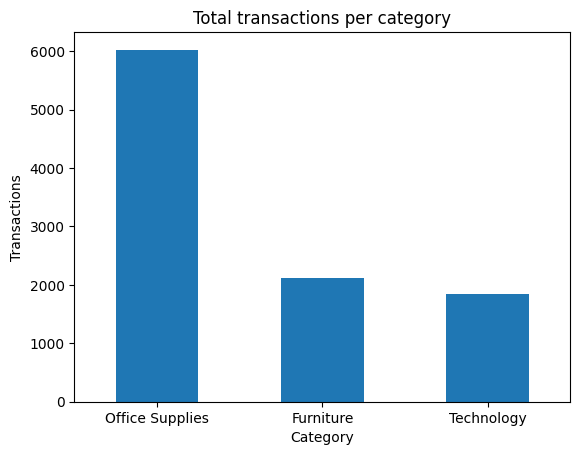

In [9]:
summed_sales = df.groupby('Category')['Sales'].count().sort_values(ascending=False)
summed_sales.plot(kind='bar')

plt.title('Total transactions per category')
plt.xlabel('Category')
plt.ylabel('Transactions')
plt.xticks(rotation=0)
plt.show()

From the dataset, it is observed that office supplies has the highest number of purchases

### Total revenue per product category ###

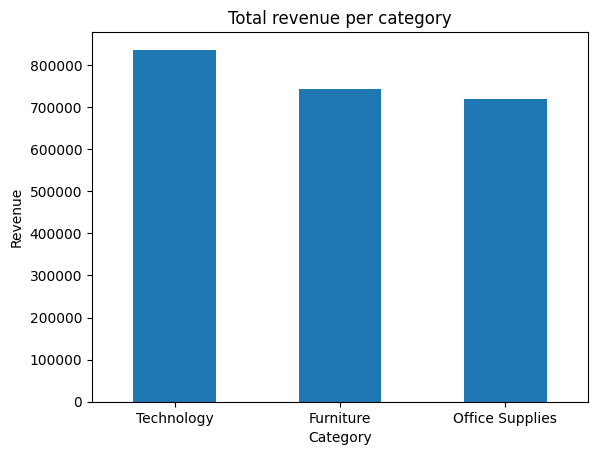

In [10]:
summed_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
summed_sales.plot(kind='bar')

plt.title('Total revenue per category')
plt.xlabel('Category')
plt.ylabel('Revenue')
plt.xticks(rotation=0)
plt.show()

Despite having the least amount of purchases, technology products generates the highest revenue as they generally have much higher unit price.

### Total revenue per subcategory ###

In [11]:
tech_df = df[df['Category'] == 'Technology']
furniture_df = df[df['Category'] == 'Furniture']
os_df = df[df['Category'] == 'Office Supplies']

tech_sales = tech_df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=True)
furniture_sales = furniture_df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=True)
os_sales = os_df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=True)

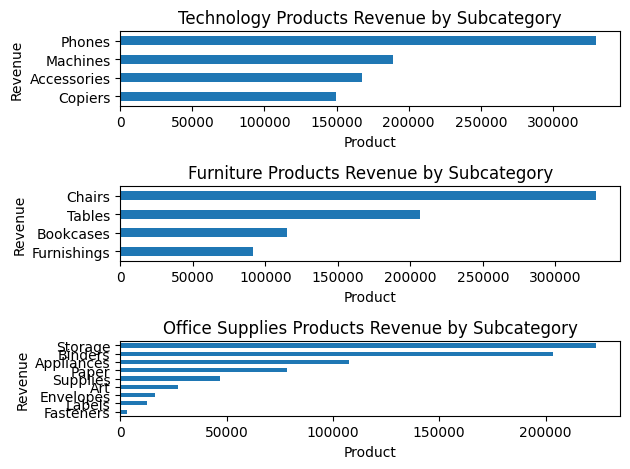

In [12]:
plt.subplot(3, 1, 1)
tech_sales.plot(kind='barh')
plt.title('Technology Products Revenue by Subcategory')
plt.xlabel('Product')
plt.ylabel('Revenue')

plt.subplot(3, 1, 2)
furniture_sales.plot(kind='barh')
plt.title('Furniture Products Revenue by Subcategory')
plt.xlabel('Product')
plt.ylabel('Revenue')

plt.subplot(3, 1, 3)
os_sales.plot(kind='barh')
plt.title('Office Supplies Products Revenue by Subcategory')
plt.xlabel('Product')
plt.ylabel('Revenue')

plt.tight_layout()
plt.show()

### Total profit per product category ###

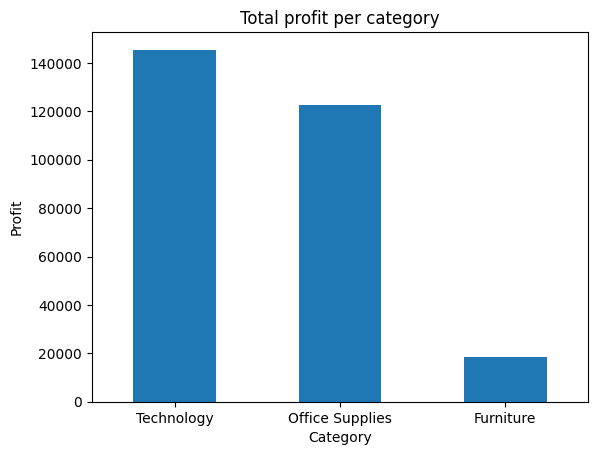

In [13]:
summed_sales = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)
summed_sales.plot(kind='bar')

plt.title('Total profit per category')
plt.xlabel('Category')
plt.ylabel('Profit')
plt.xticks(rotation=0)
plt.show()

Technology products generate the most profit, while furnitures generate a much lower total profit compared to both technology and office supples. Furniture generates high revenue per sale but typically yields lower profits because of lower margins, higher shipping and handling costs. In contrast, technology and office supplies tend to have smaller unit prices but higher profit margins, lower shipping and return costs, and often sell in higher volumes. As a result, despite lower individual prices, technology and office supplies accumulate more total profit than furniture.

### Regional Revenue ###

Since there is only one country in the dataset, we will focus on the distribution of revenue across different states.

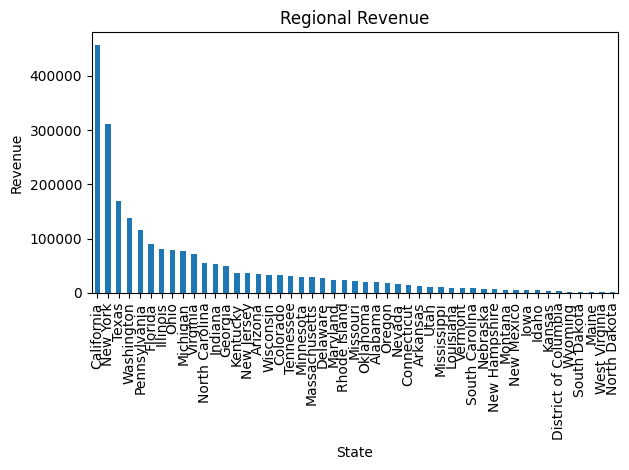

In [14]:
summed_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=False)
summed_sales.plot(kind='bar')

plt.title('Regional Revenue')
plt.xlabel('State')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

The dataset suggests significantly stronger demand in cities such as California and New York. The stronger demand in these states is likely due to larger population sizes, higher concentration of businesses, and greater purchasing power. Both states have major urban centers with dense office and commercial activity, which drives frequent orders for office supplies and technology products. Additionally, consumer spending tends to be higher in these regions, further boosting overall demand.

### Revenue Growth ###

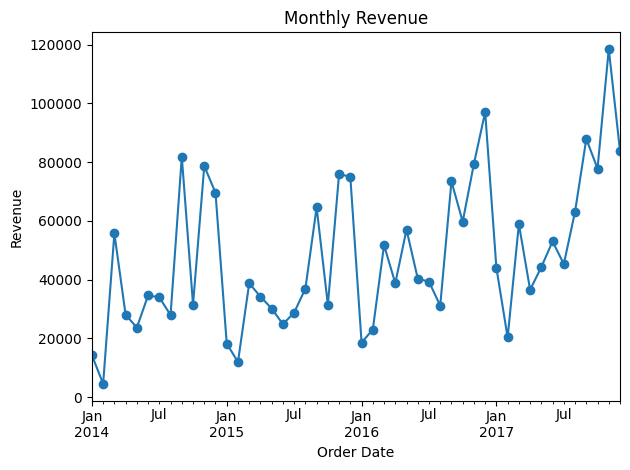

In [15]:
monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()
monthly_sales.plot(kind='line', marker='o')

plt.title('Monthly Revenue')
plt.xlabel('Order Date')
plt.ylabel('Revenue')
# plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Revenue has shown a consistent year-on-year increase, with November and December recording the highest sales each year. This seasonal spike is likely driven by Black Friday promotions and the holiday gift-giving period, highlighting the significant impact of seasonal events on overall revenue growth. Over multiple years, these months contribute disproportionately to annual sales, emphasizing the importance of targeted marketing and inventory planning during the peak season.

## Customer Segmentation ##

In [16]:
counts = df.groupby('Segment')['Customer ID'].nunique()
print(counts)

Segment
Consumer       409
Corporate      236
Home Office    148
Name: Customer ID, dtype: int64


Majority of the customers are individual consumers.

### Repeat Customers ###

In [17]:
cust_df = df.groupby('Customer ID')['Order ID'].nunique()
cust_df.head()

total_cust = df['Customer ID'].nunique()
print('Total customers:', total_cust)

repeat_cust = (cust_df > 1).sum() 
print('Repeat customers:', repeat_cust)

one_time_cust = (cust_df == 1).sum() 
print('One time customers:', one_time_cust)

Total customers: 793
Repeat customers: 781
One time customers: 12


In [18]:
total_revenue = df['Sales'].sum()
print('Total revenue:', round(total_revenue,2))
cust_revenue = df.groupby('Customer ID')['Sales'].sum().sort_values(ascending=False)
top_20 = int(0.2 * 793)
top_20_revenue = cust_revenue.nlargest(top_20).sum()
print('Revenue from top 20% spenders:', round(top_20_revenue,2))
pct_revenue = (top_20_revenue/total_revenue) * 100
print('Percentage of total revenue from top 20% spenders:', round(pct_revenue,2))

Total revenue: 2296919.49
Revenue from top 20% spenders: 1101500.01
Percentage of total revenue from top 20% spenders: 47.96


Out of 793 customers, the store has 781 repeat customers. The dataset shows extremely high customer retention, with 98.5% of customers placing multiple orders. A cumulative revenue analysis shows that the top 20% of customers contribute approximately 48% of total revenue. While higher-spending customers generate a disproportionate share of sales, revenue remains relatively distributed across the broader customer base.

### Pricing and Profitability Analysis ###

#### Effect of discounts on revenue ####

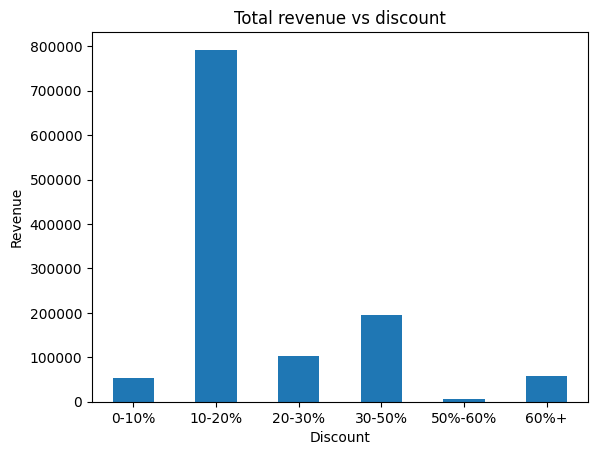

In [19]:
sales_df = df.groupby("discount_group",observed=True)["Sales"].sum()
sales_df.plot(kind='bar')

plt.title('Total revenue vs discount')
plt.xlabel('Discount')
plt.ylabel('Revenue')
plt.xticks(rotation=0)
plt.show()

Overall, discounts in the 10–20% range are associated with significantly higher revenue, suggesting that moderate promotions effectively stimulate customer demand.

#### Effect of discounts on profit ####

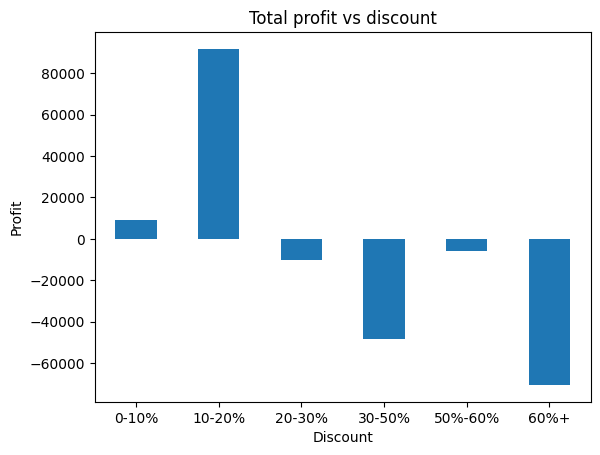

In [20]:
profit_df = df.groupby("discount_group",observed=True)["Profit"].sum()
profit_df.plot(kind='bar')

plt.title('Total profit vs discount')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.xticks(rotation=0)
plt.show()

Similar to revenue, discounts in the 10–20% range lead to substantially higher profit, indicating that moderate promotions effectively boost both sales volume and overall profitability. However, profit turns negative when discounts exceed 20%, as the reduction in per-unit margin outweighs the increase in sales, highlighting the risks of excessive discounting.

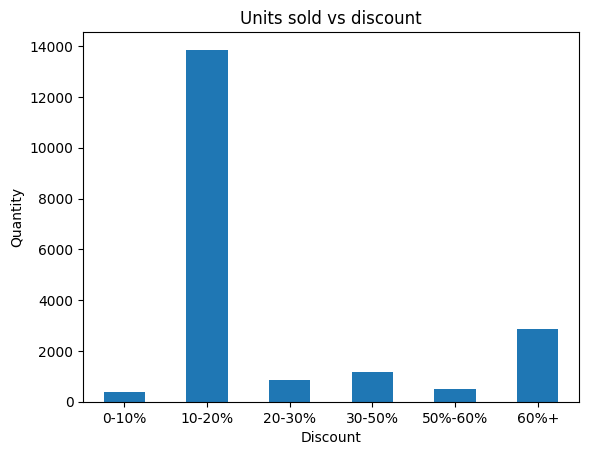

In [21]:
profit_df = df.groupby("discount_group",observed=True)["Quantity"].sum()
profit_df.plot(kind='bar')

plt.title('Units sold vs discount')
plt.xlabel('Discount')
plt.ylabel('Quantity')
plt.xticks(rotation=0)
plt.show()

Quantity sold is highest for items with 10–20% discounts because moderate promotions are typically applied to high-demand products, offering an attractive deal without signaling clearance or low quality. In contrast, deeper discounts are often used on slow-moving or niche items, resulting in smaller increases in quantity sold despite the larger price reduction.

### Analysis by Product Category ###

Different products respond differently to discounts, therefore it would be appropriate to analyse the profitability of discount schemes for different product categories.

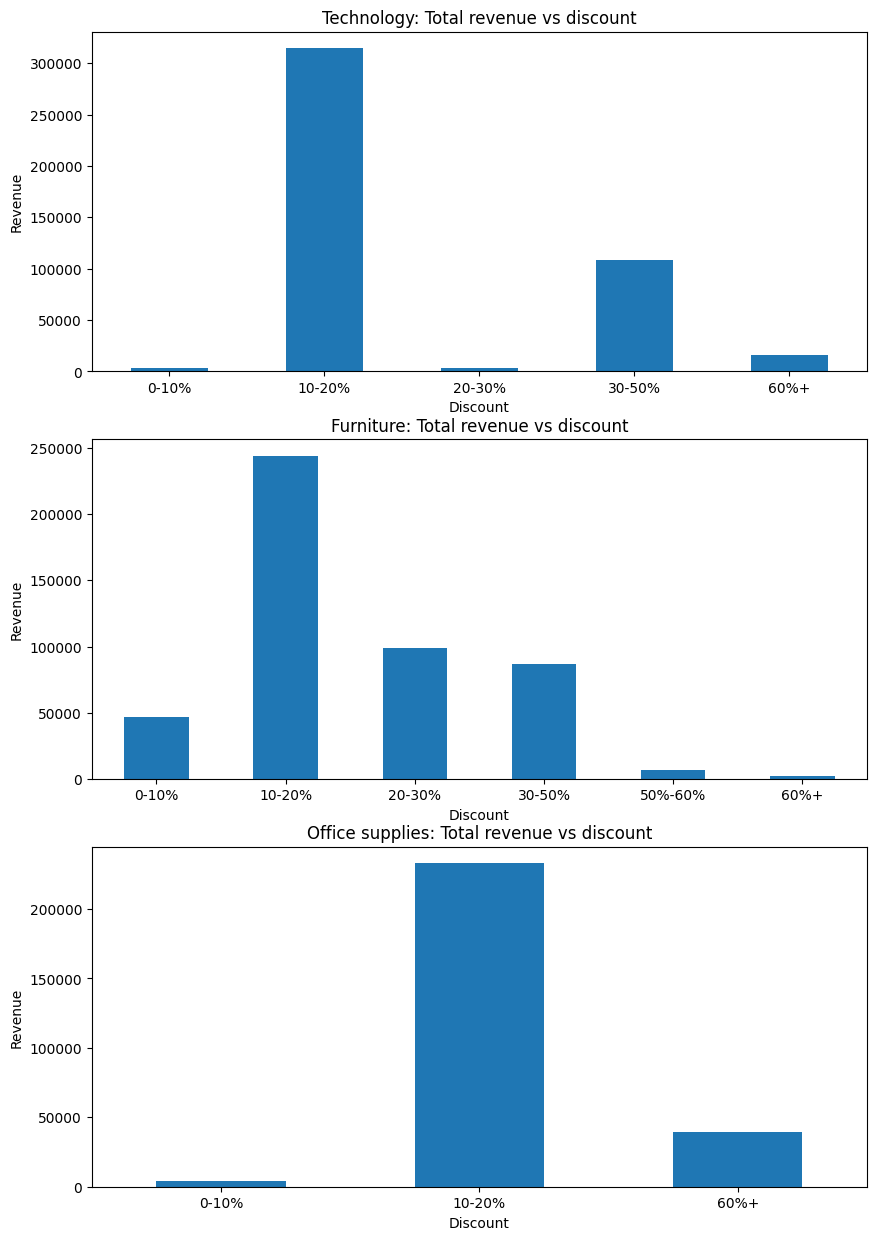

In [22]:
tech_sales_df = tech_df.groupby("discount_group",observed=True)["Sales"].sum()
furniture_sales_df = furniture_df.groupby("discount_group",observed=True)["Sales"].sum()
os_sales_df = os_df.groupby("discount_group",observed=True)["Sales"].sum()

plt.figure(figsize=(10, 15))
plt.subplot(3, 1, 1)
tech_sales_df.plot(kind='bar')
plt.title('Technology: Total revenue vs discount')
plt.xlabel('Discount')
plt.ylabel('Revenue')
plt.xticks(rotation=0)

plt.subplot(3, 1, 2)
furniture_sales_df.plot(kind='bar')
plt.title('Furniture: Total revenue vs discount')
plt.xlabel('Discount')
plt.ylabel('Revenue')
plt.xticks(rotation=0)

plt.subplot(3, 1, 3)
os_sales_df.plot(kind='bar')
plt.title('Office supplies: Total revenue vs discount')
plt.xlabel('Discount')
plt.ylabel('Revenue')
plt.xticks(rotation=0)

plt.show()

Revenue generated is highest for items with 10–20% discounts across all three product categories.

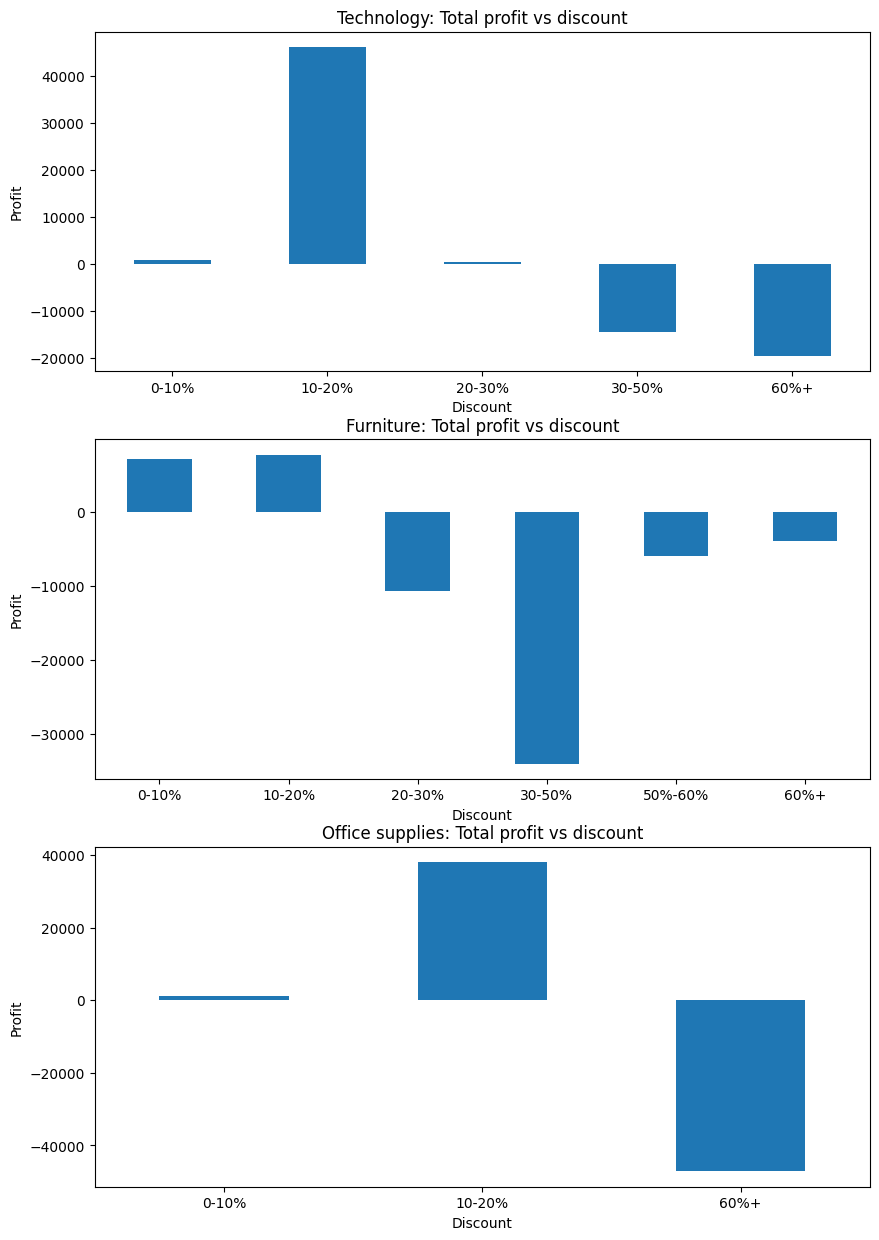

In [23]:
tech_sales_df = tech_df.groupby("discount_group",observed=True)["Profit"].sum()
furniture_sales_df = furniture_df.groupby("discount_group",observed=True)["Profit"].sum()
os_sales_df = os_df.groupby("discount_group",observed=True)["Profit"].sum()

plt.figure(figsize=(10, 15))
plt.subplot(3, 1, 1)
tech_sales_df.plot(kind='bar')
plt.title('Technology: Total profit vs discount')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.xticks(rotation=0)

plt.subplot(3, 1, 2)
furniture_sales_df.plot(kind='bar')
plt.title('Furniture: Total profit vs discount')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.xticks(rotation=0)

plt.subplot(3, 1, 3)
os_sales_df.plot(kind='bar')
plt.title('Office supplies: Total profit vs discount')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.xticks(rotation=0)

plt.show()

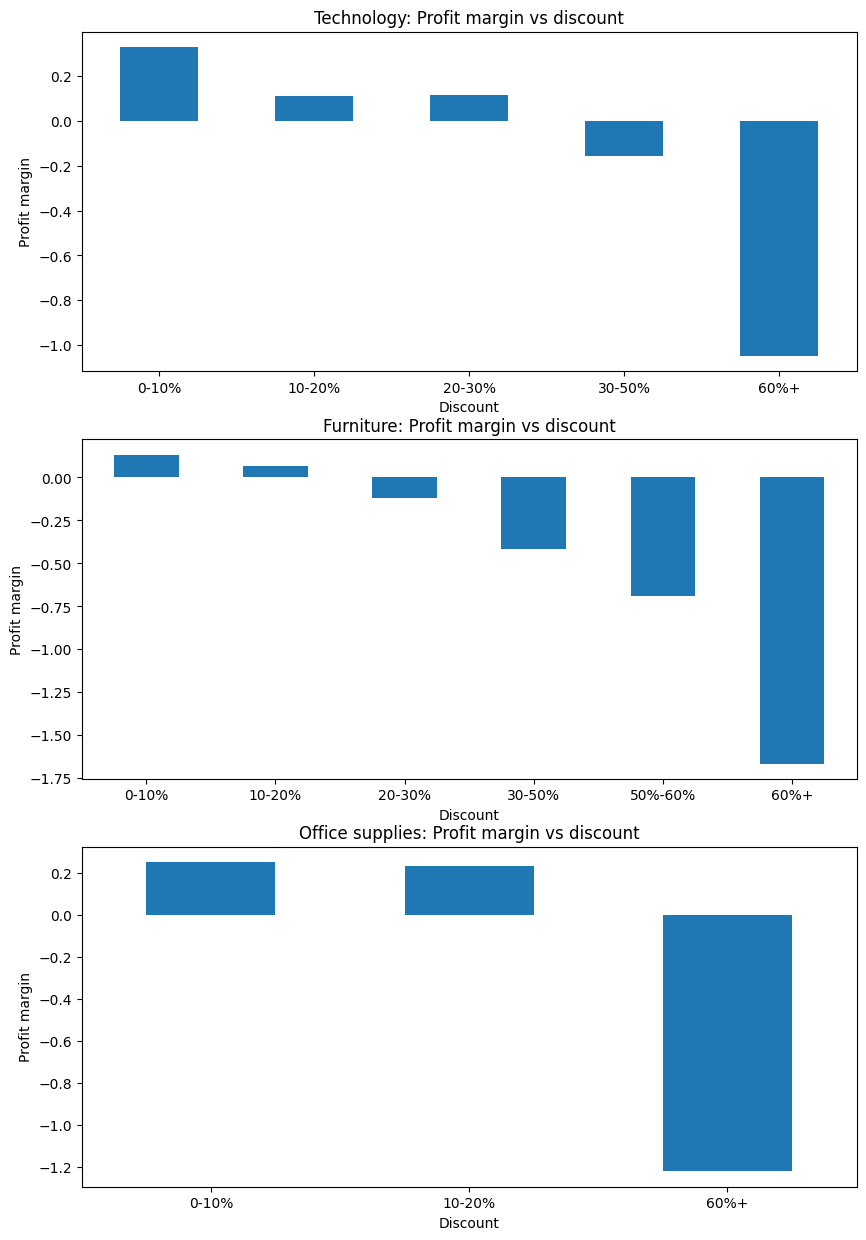

In [24]:
tech_sales_df = tech_df.groupby("discount_group",observed=True)["profit_margin"].mean()
furniture_sales_df = furniture_df.groupby("discount_group",observed=True)["profit_margin"].mean()
os_sales_df = os_df.groupby("discount_group",observed=True)["profit_margin"].mean()

plt.figure(figsize=(10, 15))
plt.subplot(3, 1, 1)
tech_sales_df.plot(kind='bar')
plt.title('Technology: Profit margin vs discount')
plt.xlabel('Discount')
plt.ylabel('Profit margin')
plt.xticks(rotation=0)

plt.subplot(3, 1, 2)
furniture_sales_df.plot(kind='bar')
plt.title('Furniture: Profit margin vs discount')
plt.xlabel('Discount')
plt.ylabel('Profit margin')
plt.xticks(rotation=0)

plt.subplot(3, 1, 3)
os_sales_df.plot(kind='bar')
plt.title('Office supplies: Profit margin vs discount')
plt.xlabel('Discount')
plt.ylabel('Profit margin')
plt.xticks(rotation=0)

# plt.tight_layout()
plt.show()

Analysis of discounts reveals that moderate promotions, specifically in the 10–20% range, are most effective in driving both revenue and profit. Revenue generated is highest for items with 10–20% discounts across all three product categories. This indicates that these promotions stimulate sales broadly without excessively eroding margins. Quantity sold is also maximized in this range, as moderate discounts are typically applied to high-demand products, offering attractive deals without signaling clearance or low quality. The total profit generated for the 10–20% discount range is higher than for items without discounts, reflecting the strategic targeting of higher-margin products. However, the effect differs by category: profit for furniture does not increase significantly with 10–20% discounts and turns negative once discounts exceed 20%, highlighting that deep discounting on high-cost, low-margin items is unprofitable. In contrast, technology products, which have higher margins, continue to generate positive profit at moderate discount levels. Overall, these findings underscore that carefully calibrated, moderate discounts can drive both volume and profitability, while excessive discounting risks eroding profits, particularly for high-cost categories like furniture.

## **Conclusion** ##

Overall, the findings demonstrate that revenue generation is influenced by multiple factors including customer purchasing behaviour, product mix, and pricing strategy.

Customer revenue analysis shows that revenue is moderately concentrated among higher-value customers, although a large portion of revenue is still generated by the broader customer base. This suggests that maintaining both customer acquisition and retention strategies is important for sustainable growth.

Discount analysis reveals a clear trade-off between sales growth and profitability. While discounts can stimulate larger order sizes and increase sales, excessive discounting significantly reduces profit margins. The results suggest that moderate discount levels in the range of 10-20% are more effective in balancing revenue growth with profitability, while aggressive promotions may lead to negative financial outcomes.

These findings highlight the importance of strategic pricing and targeted promotions in improving business performance. Future analyses could extend this work by exploring customer segmentation and marketing, targeted pricing strategies, and predictive models for demand and promotion effectiveness.